In [221]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [222]:
df = pd.read_csv('matches.csv')
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


#Viewing The Data

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [224]:
df.shape

(1095, 20)

In [225]:
df.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [226]:
df.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [227]:
df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

#Data Cleaning 

In [228]:
df.drop(["id","date","match_type","method","umpire1","umpire2","result_margin","target_overs"],axis=1, inplace = True)

In [229]:
df.head()

,season,city,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,target_runs,super_over
0,2007/08,Bangalore,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,223.0,N
1,2007/08,Chandigarh,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,241.0,N
2,2007/08,Delhi,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,130.0,N
3,2007/08,Mumbai,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,166.0,N
4,2007/08,Kolkata,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,111.0,N


In [230]:
df.isnull().sum()

season              0
city               51
player_of_match     5
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              5
result              0
target_runs         3
super_over          0
dtype: int64

In [231]:
df.dropna(subset = 'city',inplace=True)

In [232]:
df['player_of_match'] = df['player_of_match'].fillna(df['player_of_match'].mode()[0])

In [233]:
df['winner'] = df['winner'].fillna(df['winner'].mode()[0])

In [234]:
df['target_runs'] = df['target_runs'].fillna(df['target_runs'].mean())

In [235]:
df.isnull().sum()

season             0
city               0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
target_runs        0
super_over         0
dtype: int64

In [236]:
df.head()

,season,city,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,target_runs,super_over
0,2007/08,Bangalore,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,223.0,N
1,2007/08,Chandigarh,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,241.0,N
2,2007/08,Delhi,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,130.0,N
3,2007/08,Mumbai,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,166.0,N
4,2007/08,Kolkata,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,111.0,N


#EDA

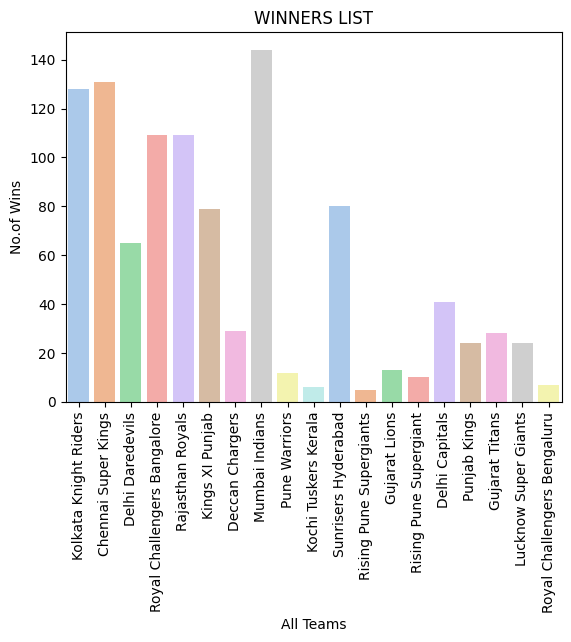

In [237]:
sns.countplot(x = df['winner'],palette ="pastel")
plt.title("WINNERS LIST")
plt.xlabel("All Teams")
plt.ylabel("No.of Wins")
plt.xticks(rotation=90)
plt.show()

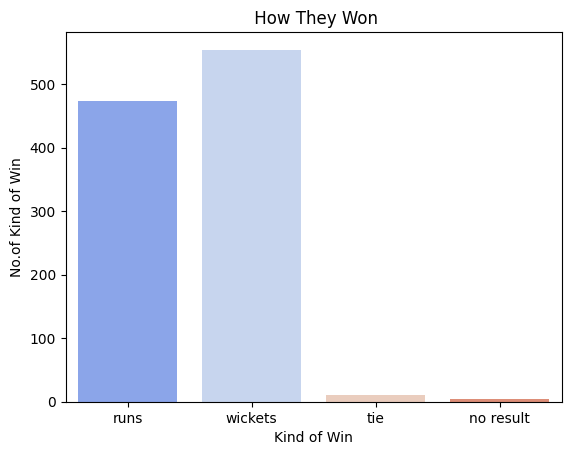

In [246]:
sns.countplot(x = df['result'],palette = "coolwarm")
plt.title(" How They Won")
plt.xlabel("Kind of Win")
plt.ylabel("No.of Kind of Win")
plt.show()

#Data Preprocessing 

In [239]:
df_Cleaned = df.copy()
df_Cleaned.head()

,season,city,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,target_runs,super_over
0,2007/08,Bangalore,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,223.0,N
1,2007/08,Chandigarh,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,241.0,N
2,2007/08,Delhi,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,130.0,N
3,2007/08,Mumbai,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,166.0,N
4,2007/08,Kolkata,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,111.0,N


In [240]:
df_Cleaned.drop_duplicates(inplace = True)

In [241]:
df_Cleaned.dtypes

season              object
city                object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
target_runs        float64
super_over          object
dtype: object

In [242]:
#One Hot Encoding 
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['season'],drop_first=True )
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['city'],drop_first=True )
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['venue'],drop_first=True )
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['team1'],drop_first=True )
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['team2'],drop_first=True )
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['toss_winner'],drop_first=True )
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['toss_decision'],drop_first=True )
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['player_of_match'],drop_first=True )
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['result'],drop_first=True )
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['winner'],drop_first=True )
df_Cleaned = pd.get_dummies(df_Cleaned,columns =['super_over'],drop_first=True )

In [243]:
df_Cleaned.head()

,target_runs,season_2009,season_2009/10,season_2011,season_2012,season_2013,season_2014,season_2015,season_2016,season_2017,...,winner_Mumbai Indians,winner_Pune Warriors,winner_Punjab Kings,winner_Rajasthan Royals,winner_Rising Pune Supergiant,winner_Rising Pune Supergiants,winner_Royal Challengers Bangalore,winner_Royal Challengers Bengaluru,winner_Sunrisers Hyderabad,super_over_Y
0,223.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,241.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,130.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,166.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,111.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [244]:
df_Cleaned = df_Cleaned.astype(int)
df_Cleaned

,target_runs,season_2009,season_2009/10,season_2011,season_2012,season_2013,season_2014,season_2015,season_2016,season_2017,...,winner_Mumbai Indians,winner_Pune Warriors,winner_Punjab Kings,winner_Rajasthan Royals,winner_Rising Pune Supergiant,winner_Rising Pune Supergiants,winner_Royal Challengers Bangalore,winner_Royal Challengers Bengaluru,winner_Sunrisers Hyderabad,super_over_Y
0,223,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,241,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,130,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,166,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,111,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,215,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1091,160,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1092,173,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1093,176,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
